# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Rayyan Muhtar Ali | 5054251051 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('jumlah baris dan kolom :', data.shape)
data.head()


jumlah baris dan kolom : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [6]:
# pandas gak nemu missing value apa pun di sini, tapi angkanya menipu, lihat cell berikutnya
print('total missing value menurut pandas :', data.isna().sum().sum())
print('jumlah baris duplikat              :', data.duplicated().sum())
print('customerID unik                    :', data['customerID'].nunique(), 'dari', len(data), 'baris')
print()
print('jumlah nilai unik tiap kolom kategorikal :')
kategorikal = [k for k in data.columns
               if k != 'customerID' and not pd.api.types.is_numeric_dtype(data[k])]
for kolom in kategorikal:
    print(' ', kolom.ljust(18), str(data[kolom].nunique()).rjust(4))


total missing value menurut pandas : 0
jumlah baris duplikat              : 0
customerID unik                    : 7043 dari 7043 baris

jumlah nilai unik tiap kolom kategorikal :
  gender                2
  Partner               2
  Dependents            2
  PhoneService          2
  MultipleLines         3
  InternetService       3
  OnlineSecurity        3
  OnlineBackup          3
  DeviceProtection      3
  TechSupport           3
  StreamingTV           3
  StreamingMovies       3
  Contract              3
  PaperlessBilling      2
  PaymentMethod         4
  TotalCharges       6531
  Churn                 2


In [7]:
# TotalCharges harusnya angka tapi kebaca sebagai teks. ternyata ada 11 baris isinya spasi,
# dan pandas gak menganggap spasi sebagai NaN makanya tadi kelihatan nol missing value.
print('tipe data TotalCharges :', data['TotalCharges'].dtype)

spasi = data['TotalCharges'].astype(str).str.strip() == ''
print('jumlah baris yang isinya spasi :', spasi.sum())
print()
print('nilai tenure pada baris-baris itu :', sorted(data.loc[spasi, 'tenure'].unique()))
print('MonthlyCharges-nya :', data.loc[spasi, 'MonthlyCharges'].tolist())
print()
print('status churn baris-baris itu :')
print(data.loc[spasi, 'Churn'].value_counts())


tipe data TotalCharges : object
jumlah baris yang isinya spasi : 11

nilai tenure pada baris-baris itu : [np.int64(0)]
MonthlyCharges-nya : [52.55, 20.25, 80.85, 25.75, 56.05, 19.85, 25.35, 20.0, 19.7, 73.35, 61.9]

status churn baris-baris itu :
Churn
No    11
Name: count, dtype: int64


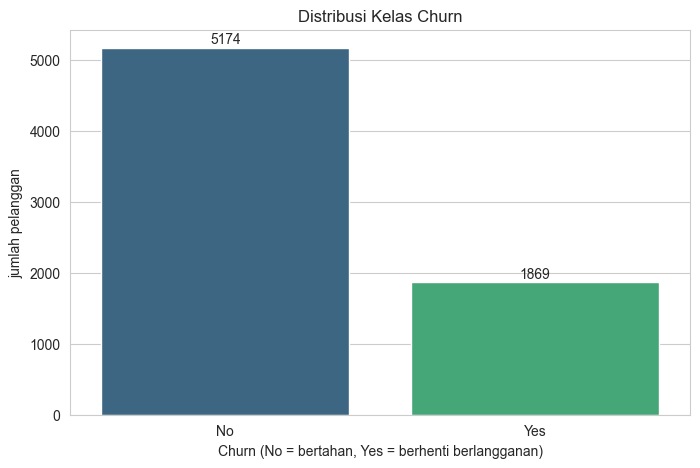

Churn
No     5174
Yes    1869
Name: count, dtype: int64

proporsi tiap kelas (%) :
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

baseline kalau semua ditebak No : 0.7346


In [8]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
jumlah = data['Churn'].value_counts()

ax = sns.barplot(x=jumlah.index, y=jumlah.values, hue=jumlah.index, palette='viridis', legend=False)
for i, v in enumerate(jumlah.values):
    ax.text(i, v + 60, str(v), ha='center')
plt.title('Distribusi Kelas Churn')
plt.xlabel('Churn (No = bertahan, Yes = berhenti berlangganan)')
plt.ylabel('jumlah pelanggan')
plt.show()

print(jumlah)
print()
print('proporsi tiap kelas (%) :')
print((data['Churn'].value_counts(normalize=True) * 100).round(2))
print()
# 73:27, timpangnya sedang. gak separah bankruptcy (97:3) tapi juga gak seimbang seperti breast cancer.
# artinya accuracy masih perlu didampingi recall dan f1 kelas churn
print('baseline kalau semua ditebak No :', round((data['Churn'] == 'No').mean(), 4))


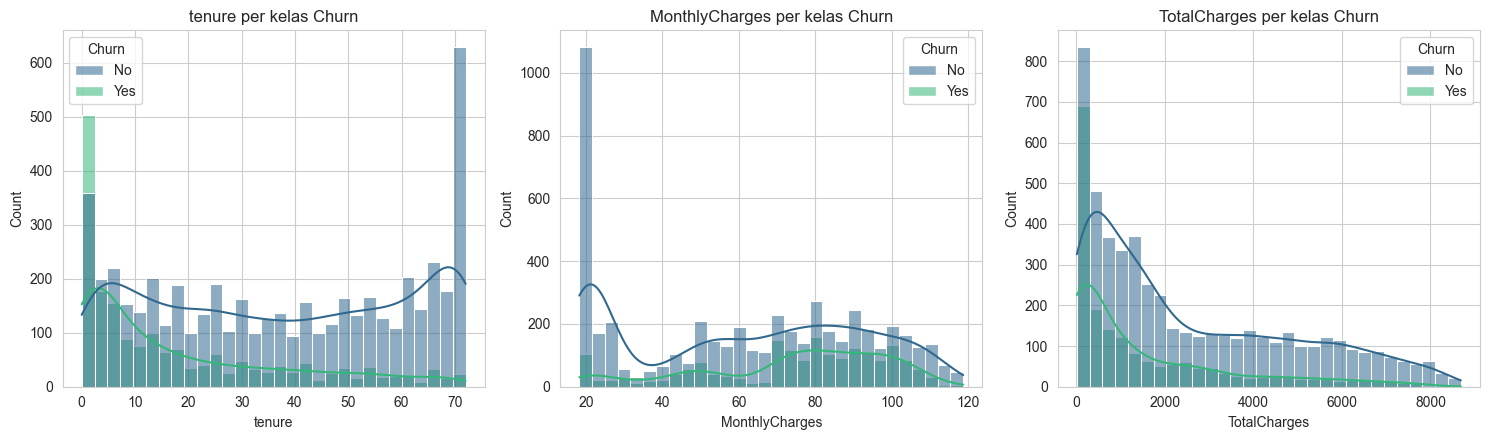

In [9]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
# fitur numeriknya cuma tiga, jadi sebarannya dilihat per kelas churn
data_plot = data.copy()
data_plot['TotalCharges'] = pd.to_numeric(data_plot['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, kolom in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=data_plot, x=kolom, hue='Churn', bins=30, kde=True,
                 palette='viridis', alpha=0.55, ax=ax)
    ax.set_title(kolom + ' per kelas Churn')
plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

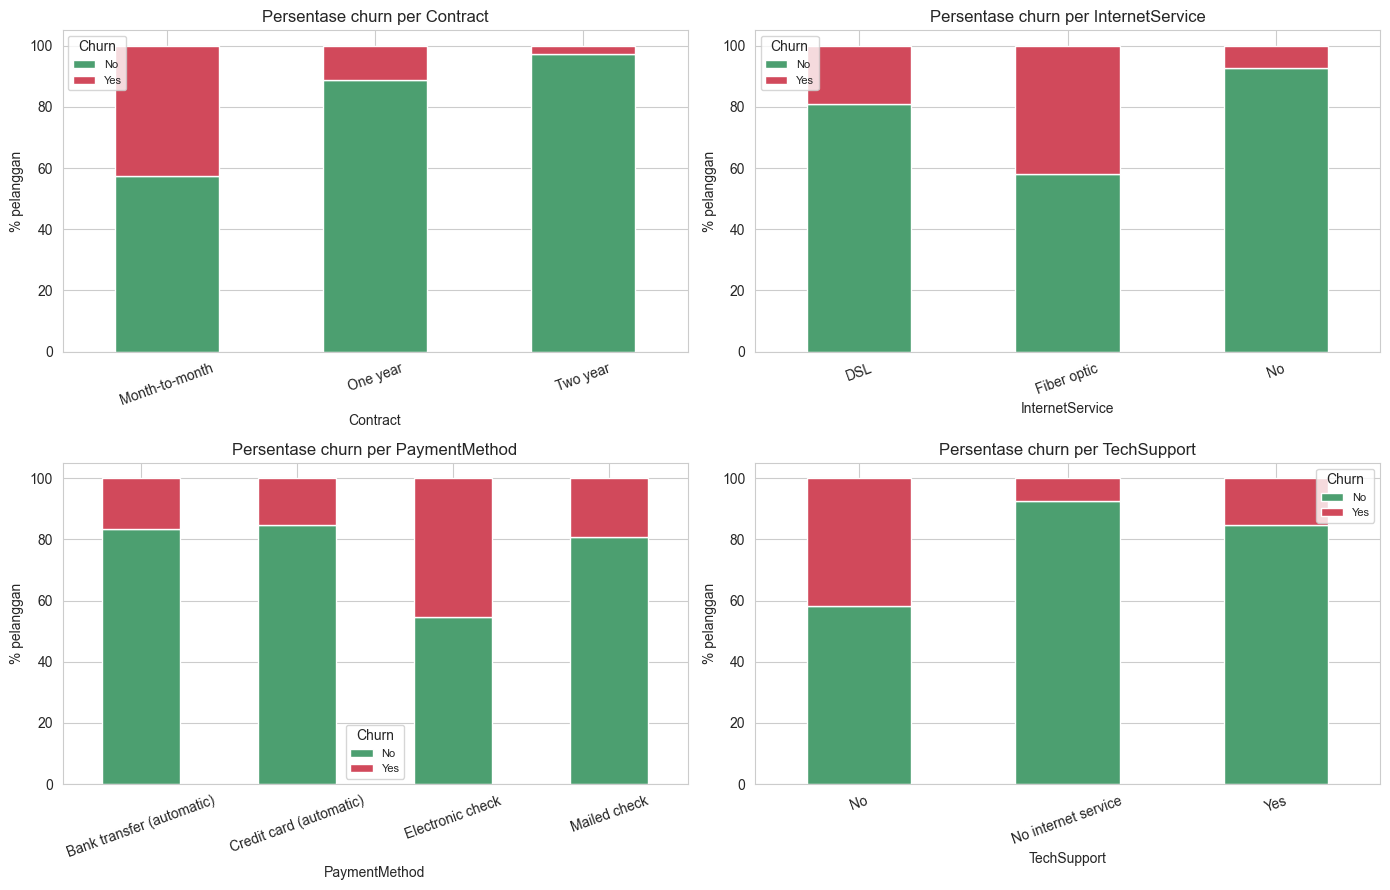

persentase churn per jenis Contract :
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [10]:
# beberapa fitur kategorikal yang saya duga paling ngaruh, dilihat sebagai proporsi churn
lihat = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, kolom in zip(axes.flatten(), lihat):
    tabel = pd.crosstab(data[kolom], data['Churn'], normalize='index') * 100
    tabel.plot(kind='bar', stacked=True, ax=ax, color=['#4c9f70', '#d1495b'], rot=20)
    ax.set_title('Persentase churn per ' + kolom)
    ax.set_ylabel('% pelanggan')
    ax.legend(title='Churn', fontsize=8)
plt.tight_layout()
plt.show()

print('persentase churn per jenis Contract :')
print((pd.crosstab(data['Contract'], data['Churn'], normalize='index') * 100).round(2))


# 2. Preprocessing

In [11]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df = data.drop(columns=['customerID'])

# TotalCharges dipaksa jadi angka, 11 baris berisi spasi tadi otomatis jadi NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('NaN setelah TotalCharges dikonversi ke angka :', df['TotalCharges'].isna().sum())
print()

# semua baris itu tenure-nya 0, artinya pelanggan yang baru daftar dan belum pernah ditagih sama sekali.
# jadi nilai yang benar memang 0, bukan mean atau median. saya isi 0 dan bukan dibuang karena
# 11 baris ini tetap informasi valid, dan angka 0 ini datang dari logika bisnisnya bukan dihitung dari data,
# jadi gak ada data leakage walaupun diisi sebelum split.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('sisa missing value :', df.isna().sum().sum())
print('shape :', df.shape)
print()
print('cek TotalCharges pelanggan tenure 0 :')
print(df.loc[df['tenure'] == 0, ['tenure', 'MonthlyCharges', 'TotalCharges']].head())


NaN setelah TotalCharges dikonversi ke angka : 11

sisa missing value : 0
shape : (7043, 20)

cek TotalCharges pelanggan tenure 0 :
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           0.0
753        0           20.25           0.0
936        0           80.85           0.0
1082       0           25.75           0.0
1340       0           56.05           0.0


In [12]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# target diubah duluan: Yes (churn) jadi 1 karena itu kelas yang mau dideteksi
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

kolom_kategorikal = [k for k in df.columns if not pd.api.types.is_numeric_dtype(df[k])]
print('kolom yang perlu di-encode :', len(kolom_kategorikal))
print(kolom_kategorikal)
print()

# semua kolom di atas nominal (gak ada urutan alami), jadi One-Hot Encoding yang cocok, bukan Ordinal.
# drop_first=True supaya gak ada kolom yang bisa ditebak dari kolom lain.
# catatan: kolom seperti OnlineSecurity punya nilai 'No internet service' yang sebenarnya informasinya
# sudah terwakili InternetService='No', jadi setelah one-hot memang ada sedikit kolom yang redundan.
df_encoded = pd.get_dummies(df, columns=kolom_kategorikal, drop_first=True)

print('shape sebelum encoding :', df.shape)
print('shape sesudah encoding :', df_encoded.shape)
print()
print('contoh kolom hasil one-hot :', list(df_encoded.columns[3:9]))
print('semua kolom sudah numerik :', all(pd.api.types.is_numeric_dtype(df_encoded[k]) or df_encoded[k].dtype == bool for k in df_encoded.columns))


kolom yang perlu di-encode : 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

shape sebelum encoding : (7043, 20)
shape sesudah encoding : (7043, 31)

contoh kolom hasil one-hot : ['TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes']
semua kolom sudah numerik : True


In [13]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_encoded.drop(columns=['Churn']).astype(float)
y = df_encoded['Churn']

print('X :', X.shape)
print('y :', y.shape)
print()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('data train :', X_train.shape)
print('data test  :', X_test.shape)
print()
print('proporsi kelas train (%) :')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print()
print('proporsi kelas test (%) :')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))
print()
print('jumlah pelanggan churn di train :', (y_train == 1).sum(), '| di test :', (y_test == 1).sum())


X : (7043, 30)
y : (7043,)



data train :

 (5634, 30)
data test  : (1409, 30)

proporsi kelas train (%) :
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

proporsi kelas test (%) :
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

jumlah pelanggan churn di train : 1495 | di test : 374


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [14]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
# ANN sama seperti SVM, tiap neuron menghitung penjumlahan berbobot dari semua fitur.
# kalau skala fiturnya beda jauh, fitur berskala besar mendominasi nilai aktivasi dan
# gradient descent-nya jadi lambat dan gak stabil.
print('rentang fitur numerik sebelum scaling :')
print(X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].agg(['min', 'max']).T.round(2))
print()

# scaler tetap di-fit cuma pakai data train supaya gak ada data leakage.
# kolom hasil one-hot ikut discaling juga, ini aman karena isinya cuma 0 dan 1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('mean train :', round(X_train_scaled.mean(), 6), '| std train :', round(X_train_scaled.std(), 6))
print('mean test  :', round(X_test_scaled.mean(), 6), '| std test  :', round(X_test_scaled.std(), 6))


rentang fitur numerik sebelum scaling :
                 min      max
tenure           0.0    72.00
MonthlyCharges  18.4   118.75
TotalCharges     0.0  8684.80

mean train : -0.0 | std train : 1.0
mean test  : -0.006592 | std test  : 0.995444


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [15]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
mlp_dasar = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                          max_iter=500, random_state=42)
mlp_dasar.fit(X_train_scaled, y_train)

print('jumlah iterasi yang terpakai :', mlp_dasar.n_iter_, 'dari max_iter 500')
print('sudah konvergen sebelum max_iter :', mlp_dasar.n_iter_ < 500)
print('loss terakhir :', round(mlp_dasar.loss_, 4))
print()
print('akurasi train :', round(mlp_dasar.score(X_train_scaled, y_train), 4))
print('akurasi test  :', round(mlp_dasar.score(X_test_scaled, y_test), 4))


jumlah iterasi yang terpakai : 241 dari max_iter 500
sudah konvergen sebelum max_iter : True
loss terakhir : 0.39

akurasi train : 0.82
akurasi test  : 0.7878


In [16]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
pred_dasar = mlp_dasar.predict(X_test_scaled)

print('10 prediksi pertama :', pred_dasar[:10])
print('10 label asli       :', y_test.values[:10])
print()
print(classification_report(y_test, pred_dasar, digits=4,
                            target_names=['bertahan (0)', 'churn (1)']))


10 prediksi pertama : [0 1 0 0 0 1 1 0 0 0]
10 label asli       : [0 0 0 0 0 0 0 0 0 1]

              precision    recall  f1-score   support

bertahan (0)     0.8420    0.8754    0.8584      1035
   churn (1)     0.6126    0.5455    0.5771       374

    accuracy                         0.7878      1409
   macro avg     0.7273    0.7104    0.7177      1409
weighted avg     0.7811    0.7878    0.7837      1409



## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [17]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
# arsitektur, max_iter, dan random_state dibikin sama persis, cuma activation yang beda
list_aktivasi = ['relu', 'tanh', 'logistic']

model_aktivasi = {}
for akt in list_aktivasi:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=akt,
                          max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    model_aktivasi[akt] = model
    print(akt.ljust(9), '-> iterasi terpakai :', str(model.n_iter_).rjust(3),
          '| loss akhir :', round(model.loss_, 4))


relu      -> iterasi terpakai : 241 | loss akhir : 0.39


tanh      -> iterasi terpakai : 431 | loss akhir : 0.3793


logistic  -> iterasi terpakai : 479 | loss akhir : 0.39


In [18]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
hasil_aktivasi = []
for akt, model in model_aktivasi.items():
    p_test = model.predict(X_test_scaled)
    hasil_aktivasi.append({
        'activation': akt,
        'iterasi': model.n_iter_,
        'akurasi_train': model.score(X_train_scaled, y_train),
        'akurasi_test': accuracy_score(y_test, p_test),
        'recall_churn': recall_score(y_test, p_test, pos_label=1, zero_division=0),
        'f1_churn': f1_score(y_test, p_test, pos_label=1, zero_division=0),
    })

hasil_aktivasi = pd.DataFrame(hasil_aktivasi)
hasil_aktivasi['selisih_train_test'] = hasil_aktivasi['akurasi_train'] - hasil_aktivasi['akurasi_test']

aktivasi_terbaik = hasil_aktivasi.loc[hasil_aktivasi['f1_churn'].idxmax(), 'activation']
print('activation terbaik menurut f1 kelas churn :', aktivasi_terbaik)
print()
hasil_aktivasi.round(4)


activation terbaik menurut f1 kelas churn : tanh



,activation,iterasi,akurasi_train,akurasi_test,recall_churn,f1_churn,selisih_train_test
0,relu,241,0.8200,0.7878,0.5455,0.5771,0.0322
1,tanh,431,0.8246,0.7935,0.5374,0.5801,0.0312
2,logistic,479,0.8156,0.7928,0.5187,0.5706,0.0228


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [19]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
# pakai activation terbaik dari 3.2, hyperparameter lain tetap sama
list_arsitektur = [(2,), (5,), (10,), (50,), (100, 50)]

model_arsitektur = {}
for arsi in list_arsitektur:
    model = MLPClassifier(hidden_layer_sizes=arsi, activation=aktivasi_terbaik,
                          max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    model_arsitektur[arsi] = model
    jumlah_bobot = sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_)
    print(str(arsi).ljust(10), '-> iterasi :', str(model.n_iter_).rjust(3),
          '| jumlah parameter :', str(jumlah_bobot).rjust(5),
          '| loss akhir :', round(model.loss_, 4))


(2,)       -> iterasi : 183 | jumlah parameter :    65 | loss akhir : 0.4121


(5,)       -> iterasi : 202 | jumlah parameter :   161 | loss akhir : 0.4022


(10,)      -> iterasi : 431 | jumlah parameter :   321 | loss akhir : 0.3793


(50,)      -> iterasi : 500 | jumlah parameter :  1601 | loss akhir : 0.2468


(100, 50)  -> iterasi : 436 | jumlah parameter :  8201 | loss akhir : 0.0973


In [20]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
hasil_arsitektur = []
for arsi, model in model_arsitektur.items():
    p_train = model.predict(X_train_scaled)
    p_test = model.predict(X_test_scaled)
    hasil_arsitektur.append({
        'arsitektur': str(arsi),
        'jumlah_neuron': sum(arsi),
        'jumlah_parameter': sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_),
        'akurasi_train': accuracy_score(y_train, p_train),
        'akurasi_test': accuracy_score(y_test, p_test),
        'recall_churn': recall_score(y_test, p_test, pos_label=1, zero_division=0),
        'f1_churn': f1_score(y_test, p_test, pos_label=1, zero_division=0),
    })

hasil_arsitektur = pd.DataFrame(hasil_arsitektur)
hasil_arsitektur['selisih_train_test'] = hasil_arsitektur['akurasi_train'] - hasil_arsitektur['akurasi_test']
hasil_arsitektur.round(4)


,arsitektur,jumlah_neuron,jumlah_parameter,akurasi_train,akurasi_test,recall_churn,f1_churn,selisih_train_test
0,"(2,)",2,65,0.8060,0.7949,0.5428,0.5842,0.0111
1,"(5,)",5,161,0.8110,0.7906,0.5187,0.5681,0.0203
2,"(10,)",10,321,0.8246,0.7935,0.5374,0.5801,0.0312
3,"(50,)",50,1601,0.8960,0.7516,0.5053,0.5192,0.1444
4,"(100, 50)",150,8201,0.9592,0.7544,0.4920,0.5154,0.2047


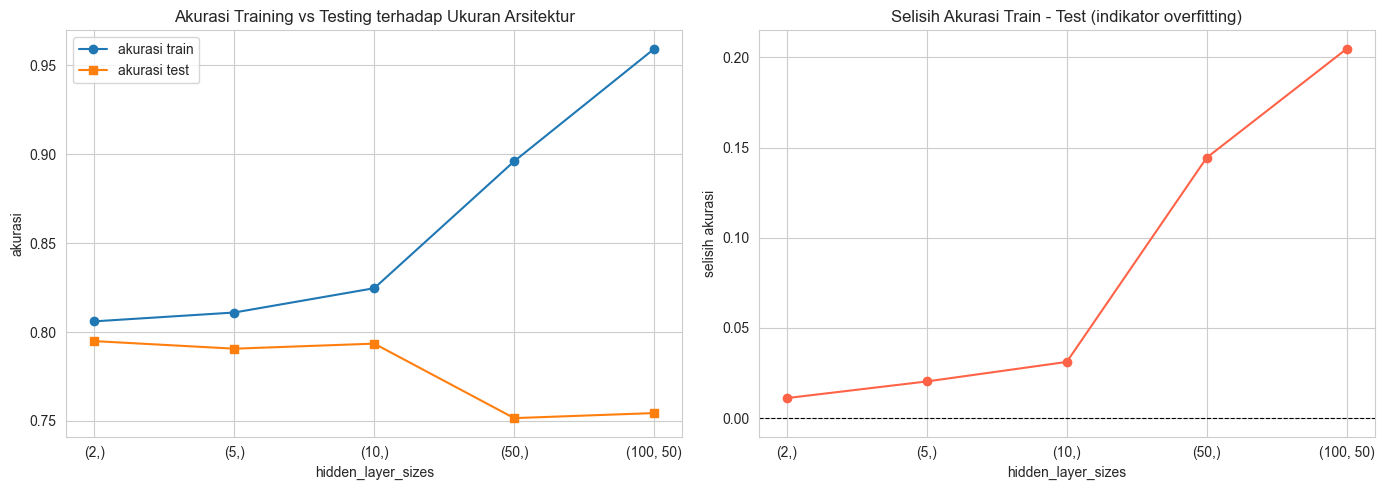

arsitektur  jumlah_parameter  akurasi_train  akurasi_test  selisih_train_test
      (2,)                65         0.8060        0.7949              0.0111
      (5,)               161         0.8110        0.7906              0.0203
     (10,)               321         0.8246        0.7935              0.0312
     (50,)              1601         0.8960        0.7516              0.1444
 (100, 50)              8201         0.9592        0.7544              0.2047


In [21]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
label_x = hasil_arsitektur['arsitektur']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(label_x, hasil_arsitektur['akurasi_train'], marker='o', label='akurasi train')
ax[0].plot(label_x, hasil_arsitektur['akurasi_test'], marker='s', label='akurasi test')
ax[0].set_title('Akurasi Training vs Testing terhadap Ukuran Arsitektur')
ax[0].set_xlabel('hidden_layer_sizes')
ax[0].set_ylabel('akurasi')
ax[0].legend()

# selisih train-test diplot terpisah karena di grafik kiri jaraknya kecil dan susah dilihat
ax[1].plot(label_x, hasil_arsitektur['selisih_train_test'], marker='o', color='tomato')
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[1].set_title('Selisih Akurasi Train - Test (indikator overfitting)')
ax[1].set_xlabel('hidden_layer_sizes')
ax[1].set_ylabel('selisih akurasi')

plt.tight_layout()
plt.show()

print(hasil_arsitektur[['arsitektur', 'jumlah_parameter', 'akurasi_train',
                        'akurasi_test', 'selisih_train_test']].round(4).to_string(index=False))


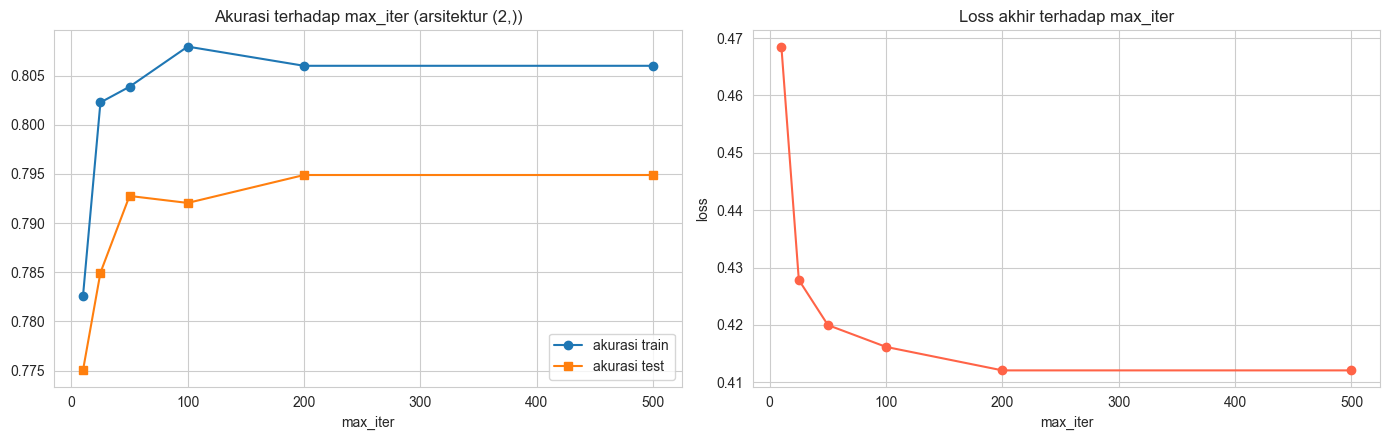

arsitektur yang dipakai : (2,) | activation : tanh

 max_iter  iterasi_terpakai  loss_akhir  akurasi_train  akurasi_test  selisih_train_test
       10                10      0.4685         0.7826        0.7750              0.0076
       25                25      0.4278         0.8023        0.7850              0.0173
       50                50      0.4200         0.8039        0.7928              0.0111
      100               100      0.4162         0.8080        0.7921              0.0159
      200               183      0.4121         0.8060        0.7949              0.0111
      500               183      0.4121         0.8060        0.7949              0.0111


In [22]:
# README tugas ini juga menyinggung pengaruh max_iter, jadi saya coba variasikan
# dengan arsitektur dan activation yang sudah terpilih
list_iter = [10, 25, 50, 100, 200, 500]
arsitektur_terbaik = list_arsitektur[hasil_arsitektur['f1_churn'].idxmax()]

hasil_iter = []
for it in list_iter:
    model = MLPClassifier(hidden_layer_sizes=arsitektur_terbaik, activation=aktivasi_terbaik,
                          max_iter=it, random_state=42)
    model.fit(X_train_scaled, y_train)
    hasil_iter.append({
        'max_iter': it,
        'iterasi_terpakai': model.n_iter_,
        'loss_akhir': model.loss_,
        'akurasi_train': model.score(X_train_scaled, y_train),
        'akurasi_test': model.score(X_test_scaled, y_test),
    })

hasil_iter = pd.DataFrame(hasil_iter)
hasil_iter['selisih_train_test'] = hasil_iter['akurasi_train'] - hasil_iter['akurasi_test']

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(hasil_iter['max_iter'], hasil_iter['akurasi_train'], marker='o', label='akurasi train')
ax[0].plot(hasil_iter['max_iter'], hasil_iter['akurasi_test'], marker='s', label='akurasi test')
ax[0].set_title('Akurasi terhadap max_iter (arsitektur ' + str(arsitektur_terbaik) + ')')
ax[0].set_xlabel('max_iter')
ax[0].legend()

ax[1].plot(hasil_iter['max_iter'], hasil_iter['loss_akhir'], marker='o', color='tomato')
ax[1].set_title('Loss akhir terhadap max_iter')
ax[1].set_xlabel('max_iter')
ax[1].set_ylabel('loss')

plt.tight_layout()
plt.show()

print('arsitektur yang dipakai :', arsitektur_terbaik, '| activation :', aktivasi_terbaik)
print()
print(hasil_iter.round(4).to_string(index=False))


# 4. Evaluasi Model

In [23]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def ringkas_metrik(nama, y_asli, y_pred):
    return {
        'model': nama,
        'accuracy': accuracy_score(y_asli, y_pred),
        'precision_churn': precision_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'recall_churn': recall_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'f1_churn': f1_score(y_asli, y_pred, pos_label=1, zero_division=0),
        'f1_macro': f1_score(y_asli, y_pred, average='macro', zero_division=0),
    }


model_akt_terbaik = model_aktivasi[aktivasi_terbaik]
model_ars_terbaik = model_arsitektur[arsitektur_terbaik]

perbandingan = pd.DataFrame([
    ringkas_metrik('3.1 dasar (10,) relu', y_test, pred_dasar),
    ringkas_metrik('3.2 terbaik: ' + aktivasi_terbaik + ' (10,)', y_test,
                   model_akt_terbaik.predict(X_test_scaled)),
    ringkas_metrik('3.3 terbaik: ' + str(arsitektur_terbaik) + ' ' + aktivasi_terbaik, y_test,
                   model_ars_terbaik.predict(X_test_scaled)),
])

# baseline: tebak "bertahan" untuk semua pelanggan
print('baseline tebak kelas mayoritas terus :', round((y_test == 0).mean(), 4))
print()
perbandingan.set_index('model').round(4)


baseline tebak kelas mayoritas terus : 0.7346



,accuracy,precision_churn,recall_churn,f1_churn,f1_macro
model,,,,,
"3.1 dasar (10,) relu",0.7878,0.6126,0.5455,0.5771,0.7177
"3.2 terbaik: tanh (10,)",0.7935,0.6301,0.5374,0.5801,0.7216
"3.3 terbaik: (2,) tanh",0.7949,0.6324,0.5428,0.5842,0.7240


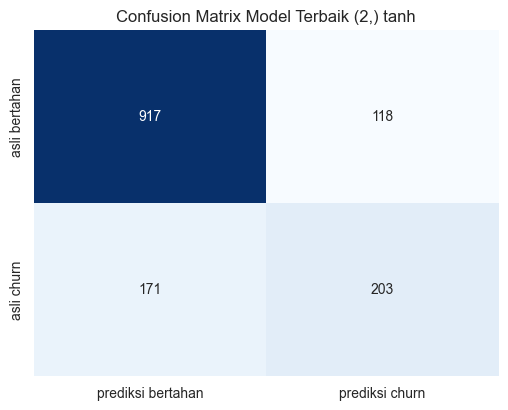

TN = 917 | FP = 118 | FN = 171 | TP = 203

dari 374 pelanggan yang benar-benar churn, model mengenali 203 dan melewatkan 171

              precision    recall  f1-score   support

bertahan (0)     0.8428    0.8860    0.8639      1035
   churn (1)     0.6324    0.5428    0.5842       374

    accuracy                         0.7949      1409
   macro avg     0.7376    0.7144    0.7240      1409
weighted avg     0.7870    0.7949    0.7896      1409



In [24]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
model_terbaik = model_ars_terbaik
pred_terbaik = model_terbaik.predict(X_test_scaled)

cm = confusion_matrix(y_test, pred_terbaik)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['prediksi bertahan', 'prediksi churn'],
            yticklabels=['asli bertahan', 'asli churn'])
plt.title('Confusion Matrix Model Terbaik ' + str(arsitektur_terbaik) + ' ' + aktivasi_terbaik)
plt.show()

tn, fp, fn, tp = cm.ravel()
print('TN =', tn, '| FP =', fp, '| FN =', fn, '| TP =', tp)
print()
print('dari', tp + fn, 'pelanggan yang benar-benar churn, model mengenali', tp,
      'dan melewatkan', fn)
print()
print(classification_report(y_test, pred_terbaik, digits=4,
                            target_names=['bertahan (0)', 'churn (1)']))


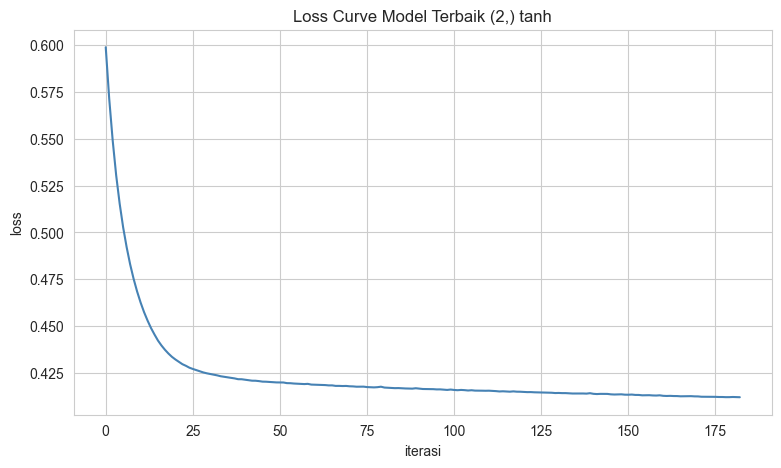

jumlah iterasi terpakai : 183 dari max_iter 500
berhenti sebelum max_iter : True
loss awal   : 0.5988
loss akhir  : 0.4121

penurunan loss selama 10 iterasi terakhir : 0.000268


In [25]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(9, 5))
plt.plot(model_terbaik.loss_curve_, color='steelblue')
plt.title('Loss Curve Model Terbaik ' + str(arsitektur_terbaik) + ' ' + aktivasi_terbaik)
plt.xlabel('iterasi')
plt.ylabel('loss')
plt.show()

print('jumlah iterasi terpakai :', model_terbaik.n_iter_, 'dari max_iter 500')
print('berhenti sebelum max_iter :', model_terbaik.n_iter_ < 500)
print('loss awal   :', round(model_terbaik.loss_curve_[0], 4))
print('loss akhir  :', round(model_terbaik.loss_curve_[-1], 4))
print()
# selisih loss di 10 iterasi terakhir dipakai buat menilai apakah kurvanya sudah mendatar
sepuluh_akhir = model_terbaik.loss_curve_[-10:]
print('penurunan loss selama 10 iterasi terakhir :',
      round(sepuluh_akhir[0] - sepuluh_akhir[-1], 6))


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Sebelum ke modelnya, ada satu hal di preprocessing yang menurut saya paling penting di tugas ini. Waktu dicek dengan `isna()`, pandas bilang dataset ini nol missing value, padahal sebenarnya ada. Kolom `TotalCharges` tersimpan sebagai teks dan ada 11 baris yang isinya spasi, dan spasi gak dianggap NaN oleh pandas. Setelah saya paksa jadi angka, 11 baris itu baru muncul sebagai NaN. Ternyata semuanya pelanggan dengan `tenure = 0`, alias baru daftar dan belum pernah ditagih. Jadi saya isi 0, bukan mean atau median, karena 0 memang nilai yang benar secara logika bisnis. Kalau saya isi pakai mean, 11 pelanggan baru ini jadi seolah-olah sudah bayar ribuan dolar.

Dari EDA, fitur yang paling kelihatan memisahkan adalah `Contract`. Pelanggan month-to-month churn-nya 42.71%, one year cuma 11.27%, dan two year cuma 2.83%. Jadi lama kontrak hampir sendirian sudah menjelaskan sebagian besar pola churn.

**Perbandingan fungsi aktivasi.** Dengan arsitektur yang sama `(10,)`, hasilnya sangat berdekatan: tanh akurasi test 0.7935, logistic 0.7928, relu 0.7878. F1 kelas churn-nya 0.5801, 0.5706, dan 0.5771. Selisih antara yang terbaik dan terburuk cuma sekitar 0.006 akurasi, yang di test set 1409 baris artinya cuma sekitar 8 pelanggan. Jadi menurut saya ketiganya praktis setara dan saya gak berani bilang tanh benar-benar lebih unggul.

Yang justru lebih kelihatan bedanya adalah kecepatan konvergensinya. Relu selesai di 241 iterasi, tanh butuh 431, dan logistic paling lambat 479 iterasi dan hampir menyentuh batas `max_iter=500`. Ini sesuai teorinya: turunan fungsi logistic maksimal cuma 0.25 sehingga gradient-nya mengecil terus waktu dirambatkan mundur, sedangkan turunan relu 1 untuk semua input positif jadi gradient-nya gak menyusut. Tanh ada di tengah-tengah karena turunannya maksimal 1 tapi tetap menjenuh di ujung. Saya tetap memakai tanh untuk eksperimen berikutnya karena F1 kelas churn-nya paling tinggi, tapi kalau datanya jauh lebih besar saya akan pilih relu karena jauh lebih cepat dengan hasil yang hampir sama.

**Eksperimen ukuran arsitektur.** Ini bagian yang hasilnya paling mengejutkan buat saya, karena arsitektur **terkecil** justru yang paling bagus. `(2,)` dengan cuma 65 parameter dapat akurasi test 0.7949 dan F1 churn 0.5842, mengalahkan `(100, 50)` yang punya 8201 parameter tapi cuma dapat 0.7544 dan F1 0.5154.

Gejala overfitting-nya terlihat sangat jelas dari selisih akurasi train dikurangi test yang naik terus seiring model membesar: 0.0111 di `(2,)`, 0.0203 di `(5,)`, 0.0312 di `(10,)`, lalu melonjak ke 0.1444 di `(50,)` dan 0.2047 di `(100, 50)`. Di grafik, kurva akurasi training naik terus dari 0.8060 sampai 0.9592, sementara kurva testing malah bergerak turun dari 0.7949 ke 0.7544. Loss akhirnya juga jatuh drastis dari 0.4121 ke 0.0973, yang artinya jaringan besar itu memang berhasil menghafal data training, cuma hafalannya gak berguna waktu ketemu pelanggan baru.

Titik mulai overfitting-nya ada di antara `(10,)` dan `(50,)`. Sampai 10 neuron selisih train-test masih di bawah 0.04 dan akurasi test masih stabil di kisaran 0.79, begitu lompat ke 50 neuron selisihnya langsung 3-4 kali lipat. Kesimpulan saya, masalah churn ini polanya relatif sederhana, jadi 2 neuron sudah cukup menangkapnya dan kapasitas tambahan cuma dipakai buat menghafal noise.

**Pengaruh max_iter.** Dengan arsitektur `(2,)` dan tanh, akurasi test naik dari 0.7750 di 10 iterasi ke 0.7949 di 200 iterasi, lalu berhenti berubah. Modelnya konvergen sendiri di iterasi 183, jadi menaikkan `max_iter` dari 200 ke 500 gak mengubah apa pun karena training sudah berhenti duluan. Dari loss curve, loss turun dari 0.5988 ke 0.4121 dan penurunan selama 10 iterasi terakhir cuma 0.000268, jadi kurvanya memang sudah benar-benar mendatar dan `max_iter=500` sudah lebih dari cukup.

**Soal performanya sendiri.** Akurasi 0.7949 kedengarannya lumayan, tapi baseline menebak "semua bertahan" saja sudah 0.7346, jadi modelnya cuma unggul sekitar 0.06 dari tebakan buta. Yang lebih jujur dilihat adalah recall kelas churn yang cuma 0.5428: dari 374 pelanggan yang benar-benar berhenti, model cuma mengenali 203 dan melewatkan 171. Untuk perusahaan yang mau mencegah pelanggan kabur, melewatkan hampir separuhnya itu masalah besar. Precision-nya 0.6324, jadi dari setiap 100 pelanggan yang diperingatkan model, sekitar 37 sebetulnya gak akan pergi.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Model terbaik yang saya dapat adalah MLPClassifier dengan **`hidden_layer_sizes=(2,)`**, **`activation='tanh'`**, dan `max_iter=500` (konvergen sendiri di iterasi 183). Hasilnya akurasi test 0.7949, precision kelas churn 0.6324, recall 0.5428, F1 0.5842, dan F1 macro 0.7240.

Pelajaran utama dari tugas ini buat saya, jaringan yang lebih besar bukan berarti lebih pintar. Model dengan 8201 parameter kalah dari model dengan 65 parameter, dan selisih akurasi train-test-nya membengkak dari 0.0111 jadi 0.2047. Sementara pilihan fungsi aktivasi ternyata hampir gak ngaruh ke akurasi (selisih ketiganya cuma sekitar 8 pelanggan dari 1409), yang kena dampaknya justru kecepatan konvergensi: relu 241 iterasi, tanh 431, logistic 479. Jadi urutan pengaruhnya di tugas ini: ukuran arsitektur jauh paling menentukan, lalu jumlah iterasi sampai titik konvergen, dan fungsi aktivasi paling kecil pengaruhnya.

Tapi kalau dinilai sebagai model yang benar-benar mau dipakai, hasil ini belum memuaskan. Akurasi 0.7949 cuma unggul 0.06 dari baseline 0.7346, dan model masih melewatkan 171 dari 374 pelanggan yang beneran churn.

Sarannya:
1. Ketimpangan kelas 73:27 perlu ditangani. `MLPClassifier` gak punya `class_weight`, jadi bisa pakai oversampling SMOTE pada data train, atau menggeser threshold keputusan lewat `predict_proba` daripada memakai 0.5. Untuk kasus churn, memperingatkan pelanggan yang ternyata gak jadi pergi jauh lebih murah daripada kehilangan pelanggan tanpa peringatan, jadi recall pantas dinaikkan walau precision turun.
2. Regularisasi `alpha` dan `early_stopping=True` layak dicoba, khususnya untuk arsitektur besar. Bisa jadi `(50,)` yang tadi overfitting sebetulnya masih bisa diselamatkan dengan regularisasi yang lebih kuat, bukan dibuang begitu saja.
3. Pemilihan arsitektur sebaiknya lewat `GridSearchCV` dengan cross validation, bukan dari akurasi test seperti yang saya lakukan sekarang.
4. Hasil one-hot masih menyisakan kolom yang redundan, misalnya `OnlineSecurity_No internet service` yang informasinya sudah terwakili oleh `InternetService_No`. Kolom seperti ini bisa dirapikan dulu supaya fiturnya lebih ramping.
5. Karena `Contract` sendirian sudah sangat kuat memisahkan (churn 42.71% di month-to-month lawan 2.83% di two year), menarik kalau hasil ANN ini dibandingkan dengan model yang lebih sederhana seperti Logistic Regression atau Decision Tree. Bisa jadi jaringan saraf memang berlebihan untuk masalah ini.